In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

ENGINE_ID = 23

np.random.seed(318)
tf.random.set_seed(318)

In [44]:
# training
train_df = pd.read_csv('../PM_train.txt', sep=" ", header=None)
if train_df.shape[1] > 26:
    train_df.drop(train_df.columns[[26, 27]], axis=1, inplace=True)

train_df.columns = [
    'id', 'cycle',
    'setting1', 'setting2', 'setting3',
    's1','s2','s3','s4','s5','s6','s7','s8','s9','s10',
    's11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21'
]

# test
test_df = pd.read_csv('../PM_test.txt', sep=" ", header=None)
if test_df.shape[1] > 26:
    test_df.drop(test_df.columns[[26, 27]], axis=1, inplace=True)

test_df.columns = train_df.columns

# truth
truth_df = pd.read_csv('../PM_truth.txt', sep=" ", header=None)
truth_df.drop(truth_df.columns[[1]], axis=1, inplace=True)
truth_df.columns = ['max']
truth_df.head()

,max
0,112
1,98
2,69
3,82
4,91


In [45]:
# сортировка
train_df = train_df.sort_values(['id', 'cycle'])

# RUL = max_cycle(id) - cycle
rul = train_df.groupby('id')['cycle'].max().reset_index()
rul.columns = ['id', 'max']
train_df = train_df.merge(rul, on='id', how='left')
train_df['RUL'] = train_df['max'] - train_df['cycle']
train_df.drop('max', axis=1, inplace=True)

# пороги
w1 = 30
w0 = 15

train_df['label1'] = np.where(train_df['RUL'] <= w1, 1, 0)
train_df['label2'] = train_df['label1']
train_df.loc[train_df['RUL'] <= w0, 'label2'] = 2

train_df['cycle_norm'] = train_df['cycle']
cols_normalize = train_df.columns.difference(['id', 'cycle', 'RUL', 'label1', 'label2'])
min_max_scaler = preprocessing.MinMaxScaler()

norm_train_df = pd.DataFrame(
    min_max_scaler.fit_transform(train_df[cols_normalize]),
    columns=cols_normalize,
    index=train_df.index
)

join_df = train_df[train_df.columns.difference(cols_normalize)].join(norm_train_df)
train_df = join_df.reindex(columns=train_df.columns)
train_df.head()

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s16,s17,s18,s19,s20,s21,RUL,label1,label2,cycle_norm
0,1,1,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.0,0.333333,0.0,0.0,0.713178,0.724662,191,0,0,0.00000
1,1,2,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.0,0.333333,0.0,0.0,0.666667,0.731014,190,0,0,0.00277
2,1,3,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.0,0.166667,0.0,0.0,0.627907,0.621375,189,0,0,0.00554
3,1,4,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.0,0.333333,0.0,0.0,0.573643,0.662386,188,0,0,0.00831
4,1,5,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.0,0.416667,0.0,0.0,0.589147,0.704502,187,0,0,0.01108


In [46]:
# нормализация теста теми же параметрами
test_df['cycle_norm'] = test_df['cycle']
norm_test_df = pd.DataFrame(
    min_max_scaler.transform(test_df[cols_normalize]),
    columns=cols_normalize,
    index=test_df.index
)
test_join_df = test_df[test_df.columns.difference(cols_normalize)].join(norm_test_df)
test_df = test_join_df.reindex(columns=test_df.columns)
test_df = test_df.reset_index(drop=True)

# генерация RUL для теста
test_df = test_df.merge(
    truth_df,
    left_on=test_df.groupby('id')['cycle'].transform('max') == test_df['cycle'],
    right_index=True,
    how='left'
)

# переносим max по id
test_rul = truth_df.copy()
test_rul['id'] = range(1, len(test_rul) + 1)
test_df = test_df.merge(test_rul, on='id', how='left', suffixes=('', '_truth'))
test_df['RUL'] = test_df['max'] - test_df['cycle']
test_df.drop(['max'], axis=1, inplace=True)

# метки
test_df['label1'] = np.where(test_df['RUL'] <= w1, 1, 0)
test_df['label2'] = test_df['label1']
test_df.loc[test_df['RUL'] <= w0, 'label2'] = 2

test_df.head()

,key_0,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,...,s17,s18,s19,s20,s21,cycle_norm,max_truth,RUL,label1,label2
0,False,1,1,0.632184,0.750000,0.0,0.0,0.545181,0.310661,0.269413,...,0.333333,0.0,0.0,0.558140,0.661834,0.00000,112,111,0,0
1,False,1,2,0.344828,0.250000,0.0,0.0,0.150602,0.379551,0.222316,...,0.416667,0.0,0.0,0.682171,0.686827,0.00277,112,110,0,0
2,False,1,3,0.517241,0.583333,0.0,0.0,0.376506,0.346632,0.322248,...,0.416667,0.0,0.0,0.728682,0.721348,0.00554,112,109,0,0
3,False,1,4,0.741379,0.500000,0.0,0.0,0.370482,0.285154,0.408001,...,0.250000,0.0,0.0,0.666667,0.662110,0.00831,112,108,0,0
4,False,1,5,0.580460,0.500000,0.0,0.0,0.391566,0.352082,0.332039,...,0.166667,0.0,0.0,0.658915,0.716377,0.01108,112,107,0,0


In [47]:
# длина временного окна
sequence_length = 50

# признаки
sensor_cols = [f's{i}' for i in range(1, 22)]
sequence_cols = ['setting1', 'setting2', 'setting3', 'cycle_norm'] + sensor_cols

len(sequence_cols), sequence_cols[:5]

(25, ['setting1', 'setting2', 'setting3', 'cycle_norm', 's1'])

In [49]:
# генерация последовательностей (как в оригинальном ноутбуке)
def gen_sequence(id_df, seq_length, seq_cols):
    data_array = id_df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length),
                           range(seq_length, num_elements)):
        yield data_array[start:stop, :]

# генерируем для всех двигателей
seq_gen = (list(gen_sequence(train_df[train_df['id'] == id_],
                             sequence_length,
                             sequence_cols))
           for id_ in train_df['id'].unique())

seq_array = np.concatenate(list(seq_gen)).astype(np.float32)
seq_array.shape

(15631, 50, 25)

In [50]:
# генерация меток для обучающих последовательностей
def gen_labels(id_df, seq_length, label_cols):
    data_array = id_df[label_cols].values
    num_elements = data_array.shape[0]
    return data_array[seq_length:num_elements, :]

label_gen = [gen_labels(train_df[train_df['id'] == id_],
                        sequence_length,
                        ['label1'])
             for id_ in train_df['id'].unique()]

label_array = np.concatenate(label_gen).astype(np.float32)
label_array.shape

(15631, 1)

In [51]:
# берём последние sequence_length шагов по каждому двигателю
seq_array_test_last = [
    test_df[test_df['id'] == id_][sequence_cols].values[-sequence_length:]
    for id_ in test_df['id'].unique()
    if len(test_df[test_df['id'] == id_]) >= sequence_length
]

seq_array_test_last = np.asarray(seq_array_test_last).astype(np.float32)
seq_array_test_last.shape

(93, 50, 25)

In [52]:
# маска тех id, у кого длина >= sequence_length, чтобы взять правильные метки
y_mask = [
    len(test_df[test_df['id'] == id_]) >= sequence_length
    for id_ in test_df['id'].unique()
]

label_array_test_last = test_df.groupby('id')['label1'].nth(-1)[y_mask].values
label_array_test_last = label_array_test_last.reshape(-1, 1).astype(np.float32)
label_array_test_last.shape

(93, 1)

In [53]:
nb_features = seq_array.shape[2]
nb_out = label_array.shape[1]

def build_model(model_type, input_shape, nb_out):
    """
    model_type: 'LSTM', 'GRU', 'RNN'
    """
    if model_type == 'LSTM':
        Layer = LSTM
    elif model_type == 'GRU':
        Layer = GRU
    elif model_type == 'RNN':
        Layer = SimpleRNN
    else:
        raise ValueError("model_type must be 'LSTM', 'GRU' or 'RNN'")

    model = Sequential()
    model.add(Layer(
        input_shape=input_shape,
        units=100,
        return_sequences=True
    ))
    model.add(Dropout(0.2))

    model.add(Layer(
        units=50,
        return_sequences=False
    ))
    model.add(Dropout(0.2))

    model.add(Dense(units=nb_out, activation='sigmoid'))
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model


In [54]:
def train_and_evaluate(model_type, seed,
                       X_train, y_train,
                       X_test, y_test,
                       epochs=10, batch_size=200):

    # фиксация сидов
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = build_model(model_type, (sequence_length, nb_features), nb_out)
    print(f"\n=== {model_type}, seed={seed} ===")
    print(model.summary())

    es = EarlyStopping(
        monitor='val_loss',
        min_delta=0,
        patience=0,
        verbose=1,
        restore_best_weights=True
    )

    # измеряем время обучения
    import time
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.05,
        verbose=1,
        callbacks=[es]
    )

    train_time = time.time() - start_time
    print(f"Train time: {train_time:.2f} sec")

    # --- метрики на train ---
    y_train_pred_prob = model.predict(X_train).ravel()
    y_train_pred = (y_train_pred_prob > 0.5).astype(int)
    y_train_true = y_train.ravel()

    loss_train, acc_train = model.evaluate(X_train, y_train, verbose=0)

    prec_train = precision_score(y_train_true, y_train_pred)
    rec_train = recall_score(y_train_true, y_train_pred)
    f1_train = f1_score(y_train_true, y_train_pred)

    # --- метрики на test ---
    y_test_pred_prob = model.predict(X_test).ravel()
    y_test_pred = (y_test_pred_prob > 0.5).astype(int)
    y_test_true = y_test.ravel()

    loss_test, acc_test = model.evaluate(X_test, y_test, verbose=0)

    prec_test = precision_score(y_test_true, y_test_pred)
    rec_test = recall_score(y_test_true, y_test_pred)
    f1_test = f1_score(y_test_true, y_test_pred)

    metrics = {
        'model_type': model_type,
        'seed': seed,
        'loss_train': loss_train,
        'acc_train': acc_train,
        'precision_train': prec_train,
        'recall_train': rec_train,
        'f1_train': f1_train,
        'loss_test': loss_test,
        'acc_test': acc_test,
        'precision_test': prec_test,
        'recall_test': rec_test,
        'f1_test': f1_test,
        'train_time_sec': train_time,
        'history': history
    }

    return model, metrics


In [55]:
seeds = [318]
model_types = ['LSTM', 'GRU', 'RNN']

all_results = []
best_model = None
best_result = None

for m_type in model_types:
    for seed in seeds:
        model, metrics = train_and_evaluate(
            m_type, seed,
            seq_array, label_array,
            seq_array_test_last, label_array_test_last,
            epochs=10,
            batch_size=200
        )
        all_results.append(metrics)
        if (best_result is None) or (metrics['f1_test'] > best_result['f1_test']):
            best_result = metrics
            best_model = model

results_df = pd.DataFrame([
    {k: v for k, v in d.items() if k != 'history'}
    for d in all_results
])
results_df


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



=== LSTM, seed=318 ===


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 50, 100)        │        50,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,651 (315.04 KB)

...

 Total params: 20,201 (78.91 KB)

 Trainable params: 20,201 (78.91 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.8942 - loss: 0.2644 - val_accuracy: 0.9335 - val_loss: 0.1855
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9514 - loss: 0.1268 - val_accuracy: 0.9527 - val_loss: 0.0927
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9525 - loss: 0.1135 - val_accuracy: 0.9335 - val_loss: 0.1556
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 2.
Train time: 25.62 sec
489/489 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


,model_type,seed,loss_train,acc_train,precision_train,recall_train,f1_train,loss_test,acc_test,precision_test,recall_test,f1_test,train_time_sec
0,LSTM,318,0.073900,0.973130,0.909035,0.960645,0.934128,3.885702,0.322581,1.0,0.284091,0.442478,87.377237
1,GRU,318,0.039905,0.982663,0.958806,0.953548,0.956170,5.673291,0.322581,1.0,0.284091,0.442478,224.491216
2,RNN,318,0.099372,0.958160,0.889739,0.900645,0.895159,3.925285,0.290323,1.0,0.250000,0.400000,25.621457


In [56]:
print("Лучший вариант по F1 на тесте:")
{k: v for k, v in best_result.items() if k != 'history'}

Лучший вариант по F1 на тесте:


{'model_type': 'LSTM',
 'seed': 318,
 'loss_train': 0.0738997533917427,
 'acc_train': 0.9731303453445435,
 'precision_train': 0.909035409035409,
 'recall_train': 0.9606451612903226,
 'f1_train': 0.9341279799247177,
 'loss_test': 3.885702133178711,
 'acc_test': 0.32258063554763794,
 'precision_test': 1.0,
 'recall_test': 0.2840909090909091,
 'f1_test': 0.4424778761061947,
 'train_time_sec': 87.37723731994629}

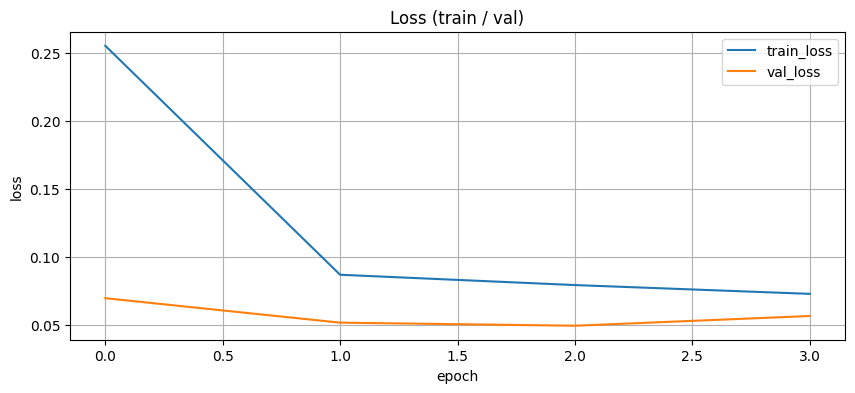

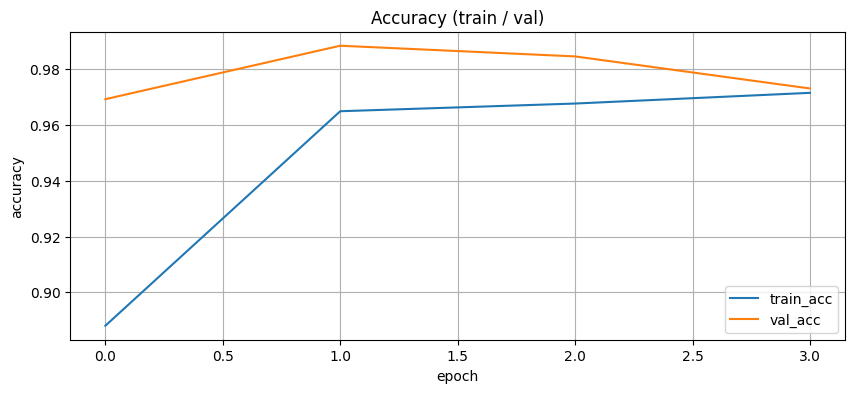

In [57]:
best_history = best_result['history']
hist = best_history.history

plt.figure(figsize=(10,4))
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss (train / val)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(hist['accuracy'], label='train_acc')
plt.plot(hist['val_accuracy'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy (train / val)')
plt.legend()
plt.grid(True)
plt.show()


In [58]:
# train
y_train_true = label_array.ravel()
y_train_pred = (best_model.predict(seq_array).ravel() > 0.5).astype(int)
cm_train = confusion_matrix(y_train_true, y_train_pred)
cm_train


489/489 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step


array([[12233,   298],
       [  122,  2978]])

In [59]:
# test
y_test_true = label_array_test_last.ravel()
y_test_pred = (best_model.predict(seq_array_test_last).ravel() > 0.5).astype(int)
cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[ 5,  0],
       [63, 25]])